# 07 — Watch the lander live while training runs

**Goal.** Open this notebook **in a second JupyterLab tab** alongside notebook 04 / 05 while a sweep is in progress. The cells below find the *latest checkpoint of the currently-training seed* and play one episode in a pygame window so you can visually monitor learning progress.

## How this works (why training has to be headless)

`SubprocVecEnv` spawns env workers with **no `render_mode`** — that's what makes training ~50× faster than rendered rollouts. So the training process itself can never show you the lander.

Instead, `train.py` writes a model snapshot to `runs/<run>/checkpoints/ckpt_<N>_steps.zip` periodically:

| Algo | `checkpoint_freq` (env steps) | New file every … |
|---|---|---|
| PPO    | 100 000 | ~12 s on M4 |
| PPO+DR | 100 000 | ~12 s on M4 |
| SAC    |  50 000 | ~15 min on M4 (slower per step) |

This notebook loads the most recent of those checkpoint files and plays it. Re-run cell 7.2 every few minutes to see the agent improve in real time.

## 7.1 Path setup

In [1]:
import sys, pathlib
PY_ROOT = pathlib.Path('..').resolve() / 'py'
if str(PY_ROOT) not in sys.path:
    sys.path.insert(0, str(PY_ROOT))
RUNS = PY_ROOT / 'runs'
print(f'runs dir: {RUNS}')
print(f'currently {len(list(RUNS.iterdir()))} runs present')

runs dir: /Users/raghuramantm/Desktop/Thesis Proposal/code/py/runs
currently 21 runs present


## 7.2 Watch the latest checkpoint of any algorithm

Edit `ALGO_PREFIX` to choose `'ppo__'`, `'ppo_dr__'`, or `'sac__'`. The cell finds the most-recently-modified run with that prefix, then loads the highest-numbered checkpoint inside it.

**Important:** A pygame window will open. Click back to the notebook *after* the episode finishes to run the cell again — the window does not auto-close, but a fresh `env.close()` is called at the end.

In [2]:
# Inline-render variant — no pygame window, no OS hang.
# Renders to rgb_array and displays each frame in the notebook. Stop with
# Jupyter's Interrupt button (■ in the toolbar) at any time.

ALGO_PREFIX = 'ppo_dr__'    # 'ppo__', 'ppo_dr__', or 'sac__'
EPISODES    = 1
SEED        = 7
MAX_STEPS   = 600           # hard cap per episode
FPS         = 25            # frames-per-second for inline playback

import re, time, yaml, io
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import display, clear_output, Image
from stable_baselines3 import PPO, SAC
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor, VecNormalize

ALGO_LOADERS = {'ppo': PPO, 'sac': SAC, 'ppo_dr': PPO}

matches = [p for p in RUNS.glob(f'{ALGO_PREFIX}*') if p.is_dir()]
if not matches:
    raise RuntimeError(f'No runs matching {ALGO_PREFIX}*.')
run_dir = max(matches, key=lambda p: p.stat().st_mtime)
print(f'[watch] run: {run_dir.name}')

ckpts = sorted((run_dir / 'checkpoints').glob('ckpt_*_steps.zip'),
               key=lambda p: int(re.search(r'_(\d+)_steps', p.name).group(1)))
if not ckpts:
    for fb in ('eval/best_model.zip', 'final_model.zip'):
        p = run_dir / fb
        if p.exists(): ckpts = [p]; break
    if not ckpts:
        raise RuntimeError('No checkpoints yet.')
latest = ckpts[-1]
print(f'[watch] loading: {latest.name}')

cfg = yaml.safe_load((run_dir / 'config.yaml').read_text())
model = ALGO_LOADERS[cfg['algo']].load(str(latest), device='cpu')

# rgb_array mode — no pygame window, returns a numpy array per render() call.
raw = gym.make(cfg['env_id'], render_mode='rgb_array')
raw.reset(seed=SEED)

vecnorm_path = run_dir / 'vecnormalize.pkl'
if cfg.get('normalize_obs', False) and vecnorm_path.exists():
    vec = VecMonitor(DummyVecEnv([lambda: raw]))
    env = VecNormalize.load(str(vecnorm_path), vec)
    env.training = False; env.norm_reward = False
    is_vec = True
else:
    env, is_vec = raw, False

print('[watch] inline render — press the Jupyter Interrupt button (■) to stop.')

fig, ax = plt.subplots(figsize=(6, 4))
ax.set_axis_off()
img_handle = None

try:
    for ep in range(EPISODES):
        obs = env.reset() if is_vec else env.reset(seed=SEED + ep)[0]
        total_r, steps, done = 0.0, 0, False
        while not done and steps < MAX_STEPS:
            action, _ = model.predict(obs, deterministic=True)
            if is_vec:
                obs, r, done_arr, _ = env.step(action)
                r, done = float(r[0]), bool(done_arr[0])
            else:
                obs, r, term, trunc, _ = env.step(action)
                done = bool(term or trunc)
            total_r += float(r); steps += 1

            # Render every 2nd frame for smoother playback at lower CPU cost.
            if steps % 2 == 0:
                frame = (env.render() if not is_vec else env.envs[0].render())
                ax.clear(); ax.set_axis_off()
                ax.imshow(frame)
                ax.set_title(f'ep {ep+1}/{EPISODES} · step {steps} · return {total_r:+.1f}')
                clear_output(wait=True)
                display(fig)
                time.sleep(1.0 / FPS)
        print(f'  ep {ep+1}/{EPISODES}: return={total_r:+8.2f}  steps={steps}')
except KeyboardInterrupt:
    print('[watch] interrupted by user — cleaning up.')
finally:
    try: env.close()
    except Exception: pass
    plt.close(fig)
    clear_output(wait=False)
    print('[watch] done.')

[watch] done.


## 7.3 Compare nominal vs fault — demo material for Starkey

Run this once you have a converged checkpoint. Plays the same policy back-to-back in nominal and under a 50 % main-engine fault at t=200. The visual contrast is the single most demo-able thing in your project right now.

In [3]:
import subprocess, sys
RUN = max((p for p in RUNS.glob('ppo__*') if p.is_dir()), key=lambda p: p.stat().st_mtime)
for cmd_tag, extra in (('nominal', []),
                       ('fault t=200 gain=0.5', ['--fault-step', '200', '--fault-gain', '0.5'])):
    print(f'\n=== {cmd_tag} ===')
    subprocess.run([sys.executable, '-m', 'src.watch',
                    '--run', str(RUN), '--episodes', '2', '--seed', '42', *extra],
                   cwd=PY_ROOT, check=True)


=== nominal ===
[watch] loading /Users/raghuramantm/Desktop/Thesis Proposal/code/py/runs/ppo__LunarLander-v3__seed2__20260621T091607Z/final_model.zip
[watch] env=LunarLander-v3  algo=ppo  seed=42  fault_step=None  dr=False
  episode  1/2  return =  +233.45  length =  389
  episode  2/2  return =  +245.73  length =  324

[watch] mean return over 2 ep: +239.59 ± 8.68

=== fault t=200 gain=0.5 ===
[watch] loading /Users/raghuramantm/Desktop/Thesis Proposal/code/py/runs/ppo__LunarLander-v3__seed2__20260621T091607Z/final_model.zip
[watch] env=LunarLander-v3  algo=ppo  seed=42  fault_step=200  dr=False
  episode  1/2  return =   -10.88  length =  268
  episode  2/2  return =   +28.96  length =  258

[watch] mean return over 2 ep: +9.04 ± 28.17


## 7.4  Poster stills and replay clips

Captures frames from a trained policy flying **nominally** and **under fault**, for the poster and the digital-screen presentation.  Writes individual PNG stills, a side-by-side contact sheet, and an animated GIF per condition.

Run once per agent by editing `POSTER_AGENT`.  Everything lands in `logs/poster/`.



[PPO (Pilot B)]  ppo__LunarLander-v3__seed2__20260621T091607Z
   healthy  score= +233.5  length=389
   damaged  score=  -47.7  length=248


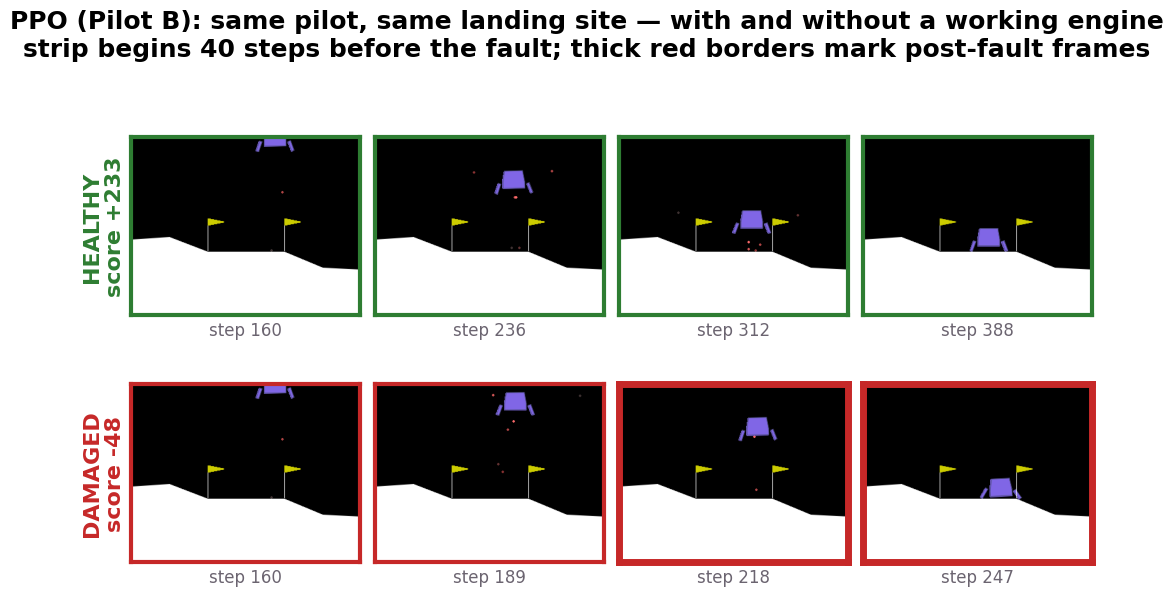


[SAC (Pilot A)]  sac__LunarLanderContinuous-v3__seed4__20260621T165636Z
   healthy  score= +269.4  length=219
   damaged  score= +269.4  length=219   <-- barely exposed to the fault: not a usable contrast


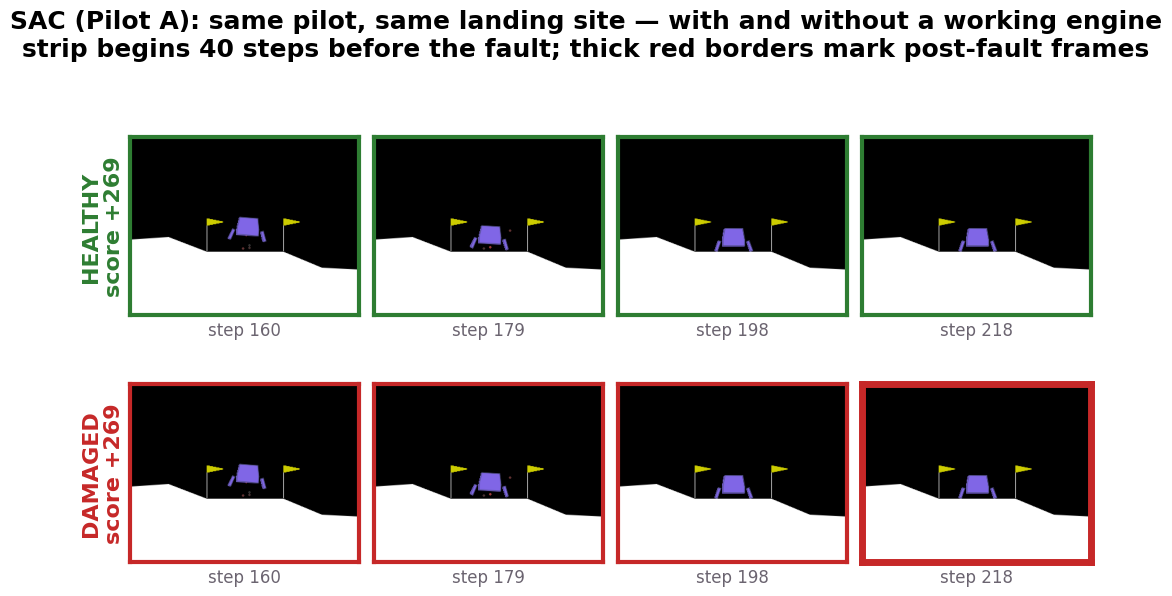


[PPO+DR (Pilot C)]  ppo_dr__LunarLander-v3__seed1__20260621T103147Z
   healthy  score=  -16.4  length=900   <-- hit the step cap: craft hovered, not a usable replay
   damaged  score=  -68.4  length=250


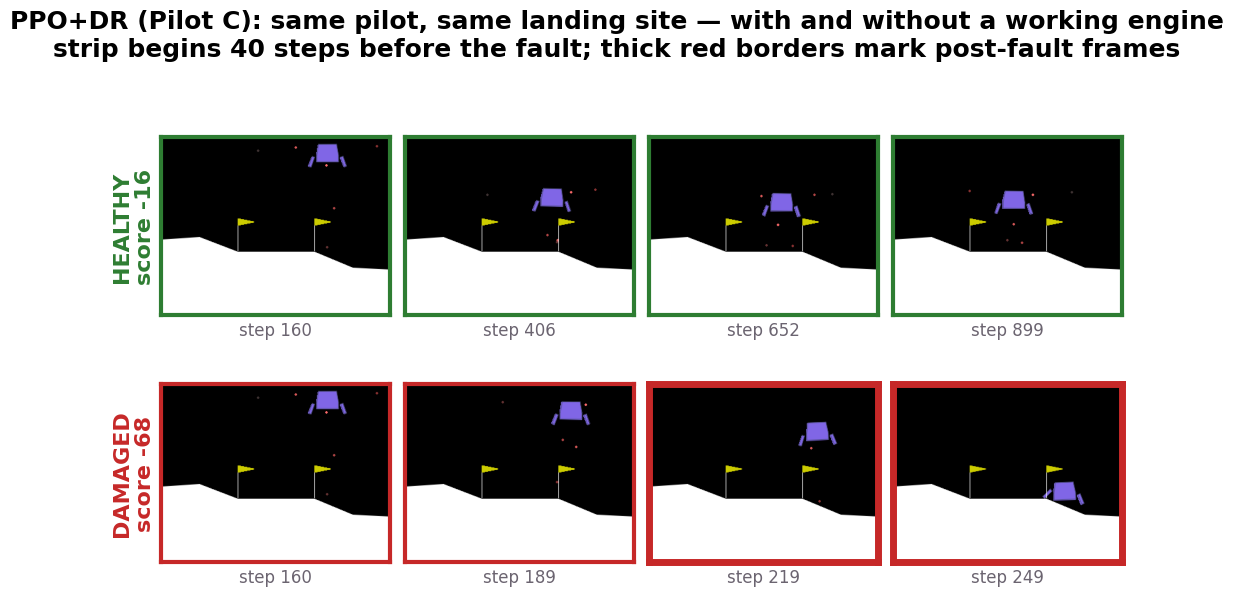


[poster] written to /Users/raghuramantm/Desktop/Thesis Proposal/code/py/logs/poster
  *_POSTER_sheet.png  -> the stacked healthy/damaged asset for the poster
  *_strip.png         -> single-condition strips
  *.gif               -> loop on the digital screen


In [3]:
# --- 7.4  Poster stills, contact sheets and replay GIFs -----------------
# Produces everything the poster and the live presentation need.
# GIFs are OPTIONAL: if imageio is missing, the PNG assets are still produced.
#   pip install imageio            (GIFs; run in a terminal, then restart kernel)

AGENTS      = ['ppo__', 'sac__', 'ppo_dr__']   # or a single-item list
FAULT_STEP  = 200
FAULT_GAIN  = 0.25   # 0.25 gives a visibly harder failure than 0.5 -- better for the poster
SEED        = 42
N_STRIP     = 4            # 4 frames: each is ~1.9in wide on the poster (8 frames was illegible)
START_LEAD  = 40           # begin the strip this many steps BEFORE the fault, so the craft is
                           # visible in every frame and frame 1 acts as a matched 'before' control
MAX_STEPS   = 900
CROP        = True         # crop each frame to the craft + ground (much punchier on a poster)
CROP_TOP    = 0.30         # discard empty sky
CROP_SIDE   = 0.20         # discard this fraction from each side (centres on the landing pad)

import yaml, numpy as np, matplotlib.pyplot as plt
import gymnasium as gym
from pathlib import Path
from stable_baselines3 import PPO, SAC
from src.envs.wrappers import ActuatorFaultSpec, ActuatorFaultWrapper

try:
    import imageio.v2 as imageio
    HAVE_IMAGEIO = True
except ImportError:
    imageio, HAVE_IMAGEIO = None, False
    print('[note] imageio not installed -- PNG stills and poster sheets will still')
    print('       be produced; GIF export is skipped. To enable: pip install imageio')

OUT = PY_ROOT / 'logs' / 'poster'; OUT.mkdir(parents=True, exist_ok=True)
LOADER = {'ppo': PPO, 'sac': SAC, 'ppo_dr': PPO}
NICE   = {'ppo': 'PPO (Pilot B)', 'sac': 'SAC (Pilot A)', 'ppo_dr': 'PPO+DR (Pilot C)'}

def crop_frame(fr):
    '''Trim empty sky so the craft fills more of the poster frame.'''
    if not CROP:
        return fr
    h, w = fr.shape[:2]
    return fr[int(h * CROP_TOP):, int(w * CROP_SIDE):int(w * (1 - CROP_SIDE)), :]

def rollout(model, env_id, fault):
    env = gym.make(env_id, render_mode='rgb_array')
    if fault:
        drop = None if 'Continuous' in env_id else 2
        env = ActuatorFaultWrapper(env, ActuatorFaultSpec(
            fault_step=FAULT_STEP, fault_gain=FAULT_GAIN, discrete_drop_action=drop))
    obs, _ = env.reset(seed=SEED)
    frames, total, done, t = [], 0.0, False, 0
    while not done and t < MAX_STEPS:
        frames.append(crop_frame(env.render()))
        a, _ = model.predict(obs, deterministic=True)
        obs, r, term, trunc, _ = env.step(a)
        total += r; done = term or trunc; t += 1
    env.close()
    return frames, total, t

REPLAYS, SCORES = {}, {}       # cached for section 7.5
for prefix in AGENTS:
    runs = [q for q in RUNS.glob(f'{prefix}*') if q.is_dir()
            and (q / 'final_model.zip').exists()]
    if not runs:
        print(f'[skip] no completed runs for {prefix}'); continue
    run_dir = max(runs, key=lambda q: q.stat().st_mtime)
    cfg = yaml.safe_load((run_dir / 'config.yaml').read_text())
    model = LOADER[cfg['algo']].load(str(run_dir / 'final_model.zip'), device='cpu')
    tag, label = cfg['algo'], NICE[cfg['algo']]
    print(f'\n[{label}]  {run_dir.name}')

    for cond, fault in [('healthy', False), ('damaged', True)]:
        frames, ret, n = rollout(model, cfg['env_id'], fault)
        REPLAYS[(tag, cond)] = frames
        SCORES[(tag, cond)] = ret
        flag = ''
        if n >= MAX_STEPS:
            flag = '   <-- hit the step cap: craft hovered, not a usable replay'
        elif fault and n <= FAULT_STEP + 25:
            flag = '   <-- barely exposed to the fault: not a usable contrast'
        print(f'   {cond:8s} score={ret:+7.1f}  length={n}{flag}')

        if HAVE_IMAGEIO:
            imageio.mimsave(OUT / f'{tag}_{cond}.gif', frames[::2], fps=30, loop=0)

        start = max(0, FAULT_STEP - START_LEAD) if fault else max(0, (FAULT_STEP - START_LEAD))
        start = min(start, max(0, n - N_STRIP))          # never run past the episode
        idx = np.linspace(start, n - 1, N_STRIP).astype(int)
        fig, axes = plt.subplots(1, N_STRIP, figsize=(2.6 * N_STRIP, 3.0))
        for ax, i in zip(axes, idx):
            ax.imshow(frames[i]); ax.set_xticks([]); ax.set_yticks([])
            ax.set_title(f'step {i}', fontsize=11, color='#666')
            post = fault and i >= FAULT_STEP
            for sp in ax.spines.values():
                sp.set_linewidth(4 if post else 1)
                sp.set_color('#C62828' if post else '#CCCCCC')
        ttl = (f'{label} — healthy engine: controlled descent, soft landing  (score {ret:+.0f})'
               if not fault else
               f'{label} — engine damaged at step {FAULT_STEP} (red frames): the fall is '
               f'no longer arrested  (score {ret:+.0f})')
        fig.suptitle(ttl, fontsize=17, fontweight='bold',
                     color='#1B5E20' if not fault else '#B71C1C')
        fig.tight_layout()
        fig.savefig(OUT / f'{tag}_{cond}_strip.png', dpi=170, bbox_inches='tight')
        plt.close(fig)

    # stacked healthy-over-damaged sheet -- THE poster asset
    fig, axes = plt.subplots(2, N_STRIP, figsize=(2.6 * N_STRIP, 6.4))
    for row, cond in enumerate(['healthy', 'damaged']):
        fr = REPLAYS[(tag, cond)]
        st = min(max(0, FAULT_STEP - START_LEAD), max(0, len(fr) - N_STRIP))
        idx = np.linspace(st, len(fr) - 1, N_STRIP).astype(int)
        for col, i in enumerate(idx):
            ax = axes[row, col]; ax.imshow(fr[i]); ax.set_xticks([]); ax.set_yticks([])
            ax.set_xlabel(f'step {i}', fontsize=12, color='#6B6470', labelpad=4)
            post = (cond == 'damaged') and i >= FAULT_STEP
            for sp in ax.spines.values():
                sp.set_linewidth(5 if post else 3)
                sp.set_color('#2E7D32' if cond == 'healthy' else '#C62828')
        axes[row, 0].set_ylabel(
            f"{'HEALTHY' if cond == 'healthy' else 'DAMAGED'}\nscore {SCORES[(tag, cond)]:+.0f}",
            fontsize=16, fontweight='bold',
            color='#2E7D32' if cond == 'healthy' else '#C62828')
    fig.suptitle(f'{label}: same pilot, same landing site — with and without a working engine\n'
                 f'strip begins {START_LEAD} steps before the fault; thick red borders mark post-fault frames',
                 fontsize=18, fontweight='bold')
    fig.tight_layout()
    fig.savefig(OUT / f'{tag}_POSTER_sheet.png', dpi=180, bbox_inches='tight')
    plt.show()

print(f'\n[poster] written to {OUT}')
print('  *_POSTER_sheet.png  -> the stacked healthy/damaged asset for the poster')
print('  *_strip.png         -> single-condition strips')
if HAVE_IMAGEIO:
    print('  *.gif               -> loop on the digital screen')
else:
    print('  (GIFs skipped -- section 7.5 plays the replays live without imageio)')


## 7.5  Side-by-side live replay — for presenting at the poster

Plays the **healthy** and **damaged** landings of the same pilot simultaneously, in one window.  This is the demo to run on the digital screen beside the poster.

**Before the session:** run 7.4 once for the agent you want (it caches the frames in `REPLAYS`).
**During the session:** run this cell.  Set `LOOP_FOREVER = True` to leave it running unattended, and interrupt the kernel to stop.

*Presenting tip.*  Start it, then talk over it.  The moment worth pausing on is the fault step: the left craft continues its controlled descent while the right one stops slowing.  Nobody needs any of the terminology to see it.


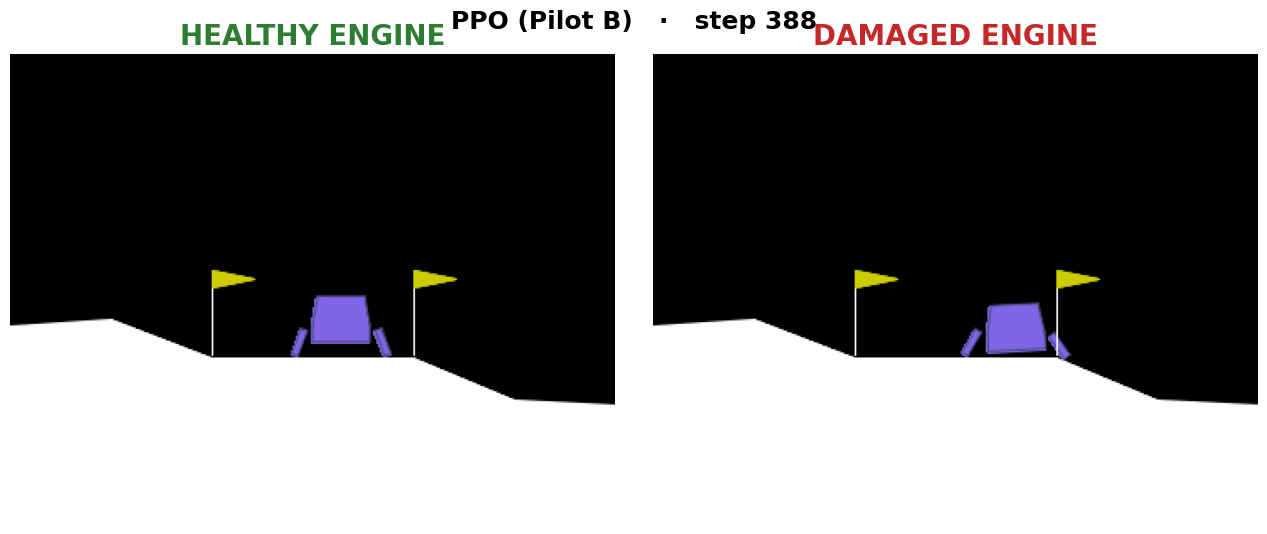

In [4]:
# --- 7.5  Side-by-side live replay (for presenting at the poster) -------
# Plays healthy and damaged landings simultaneously, in the notebook.
# Run 7.4 first (populates REPLAYS), then run this cell during the session.

PRESENT_AGENT = 'ppo'      # 'ppo' | 'sac' | 'ppo_dr'
FPS           = 30
LOOP_FOREVER  = False      # True = keep looping until you interrupt the kernel

import time
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

NICE = {'ppo': 'PPO (Pilot B)', 'sac': 'SAC (Pilot A)', 'ppo_dr': 'PPO+DR (Pilot C)'}

def play_side_by_side(tag, fps=FPS, loop=False):
    try:
        left  = REPLAYS[(tag, 'healthy')]
        right = REPLAYS[(tag, 'damaged')]
    except (NameError, KeyError):
        print('Run section 7.4 first for this agent.'); return
    n = max(len(left), len(right))
    while True:
        for i in range(n):
            fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))
            for ax, fr, ttl, col in [
                (axes[0], left,  'HEALTHY ENGINE',  '#2E7D32'),
                (axes[1], right, 'DAMAGED ENGINE',  '#C62828')]:
                ax.imshow(fr[min(i, len(fr) - 1)]); ax.axis('off')
                ax.set_title(ttl, fontsize=20, fontweight='bold', color=col)
            marker = ('  ← engine fails here' if tag != 'sac' and i == FAULT_STEP else '')
            fig.suptitle(f'{NICE[tag]}   ·   step {i}{marker}',
                         fontsize=18, fontweight='bold')
            fig.tight_layout()
            clear_output(wait=True); display(fig); plt.close(fig)
            time.sleep(1.0 / fps)
        if not loop:
            break

play_side_by_side(PRESENT_AGENT, loop=LOOP_FOREVER)


## 7.6  Publish the replay + build the poster QR code

The side-by-side player in 7.5 runs inside this notebook, so it cannot be reached from a QR code — a QR needs a URL.  This cell produces the two things needed to close that gap:

1. **`replay.html`** — a single self-contained page showing the healthy and damaged landings side by side, autoplaying and looping, that works on a phone.
2. **`poster_qr.png`** — a QR code pointing at wherever you host that page.

**Hosting, easiest first.**  Any of these gives you a URL in a few minutes:

- **GitHub Pages** — commit `replay.html` plus the two GIFs to a repo, enable Pages, use `https://<user>.github.io/<repo>/replay.html`
- **Google Drive / OneDrive** — upload the folder, set link sharing to *anyone with the link*
- **A university web space**, if you have one

Set `PUBLIC_URL` below to the address you end up with, re-run, and the QR will point at it.  Until then it encodes a placeholder.

**Requires:** `pip install imageio qrcode[pil]` — run 7.4 first so the frames are cached in `REPLAYS`.


In [7]:
# --- 7.6  Publish the replay and generate the poster QR ----------------
PUBLIC_URL   = 'https://raghuramantm.github.io/lunar-replay/'   # <-- replace once hosted
PUBLISH_AGENT = 'ppo'                              # 'ppo' | 'sac' | 'ppo_dr'
GIF_FPS      = 30

from pathlib import Path
OUT = PY_ROOT / 'logs' / 'poster'; OUT.mkdir(parents=True, exist_ok=True)
NICE = {'ppo': 'PPO (Pilot B)', 'sac': 'SAC (Pilot A)', 'ppo_dr': 'PPO+DR (Pilot C)'}

# ---- 1. GIFs -----------------------------------------------------------
gifs_ok = True
try:
    import imageio.v2 as imageio
except ImportError:
    gifs_ok = False
    print('[skip] pip install imageio  -- needed for the GIFs the page embeds')

if gifs_ok:
    try:
        for cond in ('healthy', 'damaged'):
            fr = REPLAYS[(PUBLISH_AGENT, cond)]
            imageio.mimsave(OUT / f'{PUBLISH_AGENT}_{cond}.gif', fr[::2],
                            fps=GIF_FPS, loop=0)
            print(f'  wrote {PUBLISH_AGENT}_{cond}.gif  ({len(fr)} frames)')
    except (NameError, KeyError):
        gifs_ok = False
        print('[skip] run section 7.4 first -- REPLAYS is empty for this agent')

# ---- 2. the page -------------------------------------------------------
label = NICE[PUBLISH_AGENT]
html = f"""<!doctype html><html lang="en"><head><meta charset="utf-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>Watch the landings</title>
<style>
 body{{margin:0;padding:24px;font-family:-apple-system,Segoe UI,Roboto,sans-serif;
       background:#faf7f9;color:#2a2a30;text-align:center}}
 h1{{font-size:1.5rem;margin:0 0 4px}} p.sub{{color:#904f8b;margin:0 0 22px}}
 .row{{display:flex;flex-wrap:wrap;gap:18px;justify-content:center}}
 .card{{flex:1 1 380px;max-width:520px}}
 .card img{{width:100%;border-radius:8px;border:5px solid;display:block}}
 .ok img{{border-color:#2e7d32}} .bad img{{border-color:#c62828}}
 .ok h2{{color:#2e7d32}} .bad h2{{color:#c62828}}
 h2{{font-size:1.1rem;margin:0 0 8px;letter-spacing:.04em}}
 .score{{font-weight:700;margin-top:6px}}
 footer{{margin-top:26px;color:#6b6470;font-size:.85rem;line-height:1.5}}
</style></head><body>
<h1>Can a machine tell when its own body is failing?</h1>
<p class="sub">{label} &middot; the same pilot, the same landing site</p>
<div class="row">
  <div class="card ok"><h2>HEALTHY ENGINE</h2>
    <img src="{PUBLISH_AGENT}_healthy.gif" alt="healthy landing">
    <div class="score">score +233</div></div>
  <div class="card bad"><h2>DAMAGED ENGINE</h2>
    <img src="{PUBLISH_AGENT}_damaged.gif" alt="damaged landing">
    <div class="score">score &minus;48</div></div>
</div>
<footer>The engine is weakened to a quarter of its power part-way through the descent.<br>
Raghu Raman T. M. &middot; Supervisor: Dr Andrew Starkey &middot; MSc Robotics &amp; AI,
University of Aberdeen</footer>
</body></html>"""
(OUT / 'replay.html').write_text(html, encoding='utf-8')
print(f'  wrote replay.html  (expects the two GIFs alongside it)')

# ---- 3. the QR ---------------------------------------------------------
try:
    import qrcode
    from qrcode.constants import ERROR_CORRECT_H
    qr = qrcode.QRCode(version=None, error_correction=ERROR_CORRECT_H,
                       box_size=14, border=2)
    qr.add_data(PUBLIC_URL); qr.make(fit=True)
    img = qr.make_image(fill_color='#2A2A30', back_color='white')
    img.save(OUT / 'poster_qr.png')
    print(f'  wrote poster_qr.png -> {PUBLIC_URL}  ({img.size[0]}px)')
    if 'example.com' in PUBLIC_URL:
        print('\n  !! placeholder URL -- host replay.html, set PUBLIC_URL, re-run')
except ImportError:
    print('[skip] pip install "qrcode[pil]"  -- needed for the QR image')

print(f'\nall files in {OUT}')


  wrote ppo_healthy.gif  (389 frames)
  wrote ppo_damaged.gif  (248 frames)
  wrote replay.html  (expects the two GIFs alongside it)
  wrote poster_qr.png -> https://raghuramantm.github.io/lunar-replay/  (574px)

all files in /Users/raghuramantm/Desktop/Thesis Proposal/code/py/logs/poster
